# Preliminary setups

In [1]:
import getpass
import os

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("TAVILY_API_KEY")


Provide your OPENAI_API_KEY ········
Provide your TAVILY_API_KEY ········


In [31]:
!pip install -U langgraph langchain_community langchain-tavily langchain_experimental langchain_openai

  Using cached langchain_experimental-0.3.4-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_community-0.3.31-py3-none-any.whl.metadata (3.0 kB)
INFO: pip is looking at multiple versions of langchain-experimental to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_experimental-0.3.3-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_experimental-0.3.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_experimental-0.3.1.post1-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_experimental-0.3.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_experimental-0.3.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_experimental-0.0.65-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_community-0.2.19-py3-none-any.whl.metadata (2.7 kB)
  Using cached langchain_experimental-0.0.64-py3-none-any.whl.metadata (1.7 kB)
INFO: pip is still looking at multiple versions

# All Imports 

In [2]:
from typing import Annotated, List, Optional, Dict, Literal

import os

from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool

from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import HumanMessage, trim_messages
from typing_extensions import TypedDict


USER_AGENT environment variable not set, consider setting it to identify your requests.


# Define the tools

In [35]:
@tool 
def scrape_webpages(urls: List[str]) -> str:
    """User requests and bs4 to scrape the provided web pages for detailed information"""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections"],
    file_name: Annotated[str, "File path to save the outline"],
) -> Annotated[str, "Path of the saved outline file"]: 
    """Create and save an outline"""
    # file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    file_to_use = "/Users/ssankar/Documents/ai_bites/code/langgraph-cc/temp/" + file_name
    with open(file_to_use, "w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")

    return f"Outline saved to {file_name}"

@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from"],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None
):
    """Read the specified document"""
    # file_to_use = os.path.join(os.getcwd(), file_name)
    file_to_use = "/Users/ssankar/Documents/ai_bites/code/langgraph-cc/temp/" + file_name
    with open(file_to_use, "r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "Text content to be written to the document"],
    file_name: Annotated[str, "File path to save the document"]
):
    """Create and save a text document"""
    file_to_use = "/Users/ssankar/Documents/ai_bites/code/langgraph-cc/temp/" + file_name
    with open(file_to_use, "w") as file:
        file.write(content)
    return f"Document saved to {file_name}"
        

@tool
def edit_document(
    file_name: Annotated[str, "File path to save the document"],
    insert: Annotated[Dict[int, str], "Dictionary where key is the line number and value is the text to be inserted at the line number"],
):
    """Edit a document by inserting text at specified line numbers"""
    file_to_use = os.path.join(os.getcwd(), file_name)
    with open(file_to_use, "w") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number -1, text + "\n")
        else:
            return f"Error: line number {line_number} is out of range"

    with open(file_name, "w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart"],
):
    """Use this to execute python code. If you want to see the output of any value,
    you should print it with `print(...)`. This is visible to the user"""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed: \n ```python \n{code}\n``` \n Stdout: {result}"
    

# Define the Supervisor 

In [36]:
class State(MessagesState):
    next: str

def make_supervisor_node(llm: BaseChatModel, members: List[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        next: Literal[*options]
    
    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        messages = [
            {"role": "system", "content": system_prompt}
        ] + state["messages"]
    
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END
        return Command(goto=goto, update={"next": goto})
    
    return supervisor_node

# Define the Agent Teams

## 1. Research Team

In [12]:
llm = ChatOpenAI(model = "gpt-4o")
tavily_tool = TavilySearch(max_results = 3)

search_agent = create_react_agent(llm, tools=[tavily_tool])

def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update = {
            "messages": [HumanMessage(content=result["messages"][-1].content, name="search")]
        },
        goto = "supervisor"
    )

web_scrapper_agent = create_react_agent(llm, tools=[scrape_webpages])

def web_scrapper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scrapper_agent.invoke(state)
    return Command(
        update = {
            "messages": [HumanMessage(content=result["messages"][-1].content, name="web_scrapper")]
        },
        goto = "supervisor"
    )

research_supervisor_node = make_supervisor_node(llm, ["search", "web_scrapper"])

/var/folders/sc/2r6rbq2x6zsd6hq3mjg5f73c0000gn/T/ipykernel_16391/1270557768.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  search_agent = create_react_agent(llm, tools=[tavily_tool])
/var/folders/sc/2r6rbq2x6zsd6hq3mjg5f73c0000gn/T/ipykernel_16391/1270557768.py:15: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  web_scrapper_agent = create_react_agent(llm, tools=[scrape_webpages])


In [13]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scrapper", web_scrapper_node)

research_builder.add_edge(START, "supervisor")
research_graph = research_builder.compile()


In [30]:
for s in research_graph.stream(
    {"messages" : [("user", "what is the weather like in Porto today?")]},
    {"recursion_limit": 20},
): 
    print(s)
    print("---")

{'supervisor': {'next': 'search'}}
---
{'search': {'messages': [HumanMessage(content="I couldn't find the specific weather information for Porto today. You may want to check a reliable weather website like Weather.com or a local news site for current updates on Porto's weather.", additional_kwargs={}, response_metadata={}, name='search', id='bc421bf6-4bdd-4587-b1ee-cf89c0130558')]}}
---
{'supervisor': {'next': 'web_scrapper'}}
---
{'web_scrapper': {'messages': [HumanMessage(content="I currently don't have access to real-time data, including weather updates. To find out the current weather in Porto, please check a weather website or app like Weather.com, BBC Weather, or a local news source for the latest information.", additional_kwargs={}, response_metadata={}, name='web_scrapper', id='f6afa9ef-6a3b-4d6b-ba03-9167de007ef4')]}}
---
{'supervisor': {'next': '__end__'}}
---


## 2. Writing Team

In [37]:
doc_writer_agent = create_react_agent(
    llm, 
    tools = [write_document, edit_document, read_document],
    prompt = (
        "You can read, write and edit documents based on note taker's outlines. "
        "Don't ask follow up questions."
    )
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update = {
            "messages": [
                HumanMessage(content = result["messages"][-1].content, name = "doc_writer")
            ]
        },
        goto = "supervisor",
    )

note_taking_agent = create_react_agent(
    llm,
    tools = [create_outline, read_document],
    prompt = (
        "You can read documents and create outlines for the document writer."
        "Don't ask follow up questions."
    )
)


def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update = {
            "messages": [
                HumanMessage(content = result["messages"][-1].content, name = "note_taker")
            ]
        },
        goto = "supervisor",
    )

chart_generating_agent = create_react_agent(
    llm, tools = [read_document, python_repl_tool]
)

def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update = {
            "messages": [
                HumanMessage(content = result["messages"][-1].content, name = "chart_generator")
            ]
        },
        goto = "supervisor",
    )

doc_writing_supervisor_node = make_supervisor_node(
    llm, ["doc_writer", "note_taker", "chart_generator"]
)


/var/folders/sc/2r6rbq2x6zsd6hq3mjg5f73c0000gn/T/ipykernel_16391/3597590286.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  doc_writer_agent = create_react_agent(
/var/folders/sc/2r6rbq2x6zsd6hq3mjg5f73c0000gn/T/ipykernel_16391/3597590286.py:21: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  note_taking_agent = create_react_agent(
/var/folders/sc/2r6rbq2x6zsd6hq3mjg5f73c0000gn/T/ipykernel_16391/3597590286.py:42: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_generating_agent = create

In [38]:
writing_builder = StateGraph(State)
writing_builder.add_node("supervisor", doc_writing_supervisor_node)
writing_builder.add_node("doc_writer", doc_writing_node)
writing_builder.add_node("note_taker", note_taking_node)
writing_builder.add_node("chart_generator", chart_generating_node)

writing_builder.add_edge(START, "supervisor")
writing_graph = writing_builder.compile()

In [27]:
for s in writing_graph.stream(
    {
        "messages": [
            (
                "user",
                "Write an outline for a poem about dogs and after that write the poem itself and store it"
            )
        ]
    },
    {"recursion_limit": 30}
):
    print(s)
    print("---")
    

{'supervisor': {'next': 'note_taker'}}
---
{'note_taker': {'messages': [HumanMessage(content='The outline for the poem about dogs has been created and saved.', additional_kwargs={}, response_metadata={}, name='note_taker', id='4875ab5c-36bd-48ed-bcb8-cd99c00d3fc5')]}}
---
{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='I have written the poem titled "The Joy of Dogs" and saved both the outline and the final poem.', additional_kwargs={}, response_metadata={}, name='doc_writer', id='be3ffe47-a60d-4e12-9706-095869091552')]}}
---
{'supervisor': {'next': '__end__'}}
---


# End-to-end Graph

## Implement the graph

In [39]:
teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update = {
            "messages" : [
                HumanMessage(
                    content=response["messages"][-1].content, name = "research_team"
                )
            ]
        },
        goto="supervisor"
    )

def call_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update = {
            "messages" : [
                HumanMessage(
                    content=response["messages"][-1].content, name = "writing_team"
                )
            ]
        },
        goto="supervisor"
    )

super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_writing_team)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

## Visualize the graph

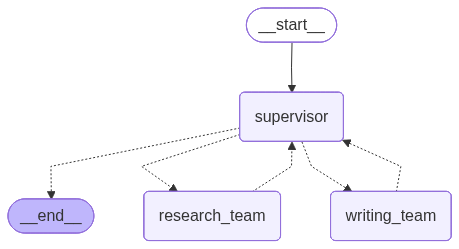

In [40]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))


## Run the graph

In [41]:
for s in super_graph.stream(
    {
        "messages": [
            ("user", "Research why the gold price has been increasing crazily in 2025. Come up with the reasons and compile a report. Do not try to generate any charts or plots. Just a report with text and numbers will do.")
        ]
    },
    {"recursion_limit": 1000}
):
    print(s)
    print("....")

{'supervisor': {'next': 'research_team'}}
....
{'research_team': {'messages': [HumanMessage(content="In 2025, the gold market witnessed a profound upsurge, with prices exceeding $4,000 per ounce, which is approximately a 49% increase. Several interwoven factors contributed to this significant surge, and understanding these elements provides a clear picture of why gold became highly valued:\n\n1. **Economic Uncertainty**: The global economic environment was rife with instability and unpredictability, compelling investors to seek refuge in safe-haven assets like gold. Historically, gold is regarded as a reliable store of value during turbulent times. During 2025, the unpredictability of economic performance and markets drove a substantial number of investors towards gold, intensifying its demand and driving up the price.\n\n2. **Geopolitical Tensions**: The era was marked by increased geopolitical conflicts and tensions, which naturally heighten economic volatility. Regions experiencing 

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-pZoY99amfKuuAe0cNK7ghahP on tokens per min (TPM): Limit 30000, Used 26134, Requested 3870. Please try again in 8ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}